# 01 — Data Exploration: DLX Shotgun Demand

**CIS 731 Term Project — Brent Showalter**

This notebook profiles the raw NASGW SCOPE DLX transaction data (2019–2023),
documents key data quality findings, and verifies the processed pipeline output.

**Prerequisites:** Run `spark_pipeline.py` first so that processed Parquet exists
at `data/processed/`.

---
## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    FloatType,
    IntegerType,
    StringType,
    StructField,
    StructType,
)

# Add project root to path so config is importable
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import load_config

# Plotting defaults
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

# Load config
config = load_config(str(PROJECT_ROOT / "config" / "settings.yaml"))
RAW_DIR = PROJECT_ROOT / config["paths"]["data_raw"]
PROCESSED_DIR = PROJECT_ROOT / config["paths"]["data_processed"]
YEARS = list(range(config["data"]["years"]["start"], config["data"]["years"]["end"] + 1))

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir: {RAW_DIR}")
print(f"Processed dir: {PROCESSED_DIR}")
print(f"Years: {YEARS}")

Project root: /Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final
Raw data dir: /Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw
Processed dir: /Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/processed
Years: [2019, 2020, 2021, 2022, 2023]


In [2]:
# Create Spark session
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("DataExploration")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/26 16:35:04 WARN Utils: Your hostname, Brents-Mac-mini.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.209 instead (on interface en1)
26/02/26 16:35:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/02/26 16:35:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


In [3]:
# Raw schema (explicit — no inferSchema)
RAW_SCHEMA = StructType([
    StructField("type", StringType(), True),
    StructField("category", StringType(), True),
    StructField("subcategory", StringType(), True),
    StructField("sizing", StringType(), True),
    StructField("month_name", StringType(), True),
    StructField("month_number", IntegerType(), True),
    StructField("year_", IntegerType(), True),
    StructField("tactical", StringType(), True),
    StructField("barrel_length", FloatType(), True),
    StructField("trigger_action", StringType(), True),
    StructField("quantity", IntegerType(), True),
    StructField("amount", FloatType(), True),
])

---
## 2. Raw Data Profile

Load each of the five yearly CSV files and examine schema, shape, and basic statistics.

In [4]:
# Load individual year files and record row counts
year_dfs = {}
year_counts = {}

for year in YEARS:
    path = str(RAW_DIR / f"dlx_shotgun_datadump_firearms_{year}.csv")
    df = spark.read.csv(path, schema=RAW_SCHEMA, header=True)
    year_dfs[year] = df
    year_counts[year] = df.count()

print("Row counts by year:")
for year, count in year_counts.items():
    print(f"  {year}: {count:,}")
print(f"  Total: {sum(year_counts.values()):,}")

Row counts by year:
  2019: 2,595
  2020: 2,747
  2021: 3,027
  2022: 3,290
  2023: 3,522
  Total: 15,181


In [5]:
# Union all years into a single DataFrame
from functools import reduce
from pyspark.sql import DataFrame

raw_df = reduce(DataFrame.unionByName, year_dfs.values())
raw_df = raw_df.withColumn(
    "date", F.make_date(F.col("year_"), F.col("month_number"), F.lit(1))
)

print(f"Combined shape: ({raw_df.count():,} rows, {len(raw_df.columns)} columns)")
print("\nSchema:")
raw_df.printSchema()

Combined shape: (15,181 rows, 13 columns)

Schema:
root
 |-- type: string (nullable = true)
 |-- category: string (nullable = true)
 |-- subcategory: string (nullable = true)
 |-- sizing: string (nullable = true)
 |-- month_name: string (nullable = true)
 |-- month_number: integer (nullable = true)
 |-- year_: integer (nullable = true)
 |-- tactical: string (nullable = true)
 |-- barrel_length: float (nullable = true)
 |-- trigger_action: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- amount: float (nullable = true)
 |-- date: date (nullable = true)



In [6]:
# Sample rows
raw_df.show(5, truncate=False)

26/02/26 16:37:33 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'type', b'category', b'subcategory', b'sizing', b'month_name', b'month_number', b'year_', b'tactical', b'barrel_length', b'trigger_action', b'quantity', b'amount'
 Schema: type, category, subcategory, sizing, month_name, month_number, year_, tactical, barrel_length, trigger_action, quantity, amount
Expected: type but found: b'type'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv


+--------+--------+-----------+------+----------+------------+-----+--------+-------------+--------------+--------+---------+----------+
|type    |category|subcategory|sizing|month_name|month_number|year_|tactical|barrel_length|trigger_action|quantity|amount   |date      |
+--------+--------+-----------+------+----------+------------+-----+--------+-------------+--------------+--------+---------+----------+
|Firearms|Shotgun |Pump Action|20 GA |Jan       |1           |2019 |N       |26.0         |OTHER         |605     |123232.97|2019-01-01|
|Firearms|Shotgun |Pump Action|20 GA |Apr       |4           |2019 |N       |24.0         |OTHER         |253     |87552.19 |2019-04-01|
|Firearms|Shotgun |Pump Action|12 GA |Mar       |3           |2019 |N       |NULL         |OTHER         |2343    |746002.75|2019-03-01|
|Firearms|Shotgun |Pump Action|12 GA |Apr       |4           |2019 |Y       |20.0         |OTHER         |1898    |674533.6 |2019-04-01|
|Firearms|Shotgun |Over/Under |12 GA |Apr

In [7]:
# Summary statistics for numeric columns
raw_df.select("barrel_length", "quantity", "amount").describe().show()

26/02/26 16:37:39 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'barrel_length', b'quantity', b'amount'
 Schema: barrel_length, quantity, amount
Expected: barrel_length but found: b'barrel_length'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:37:39 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'barrel_length', b'quantity', b'amount'
 Schema: barrel_length, quantity, amount
Expected: barrel_length but found: b'barrel_length'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:37:39 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'barrel_length', b'quantity', b'amount'
 Schema: barrel_length, quantity, amount
Expected: barrel_length but found: b'barrel_length'
CSV file: file:///Users/bre

26/02/26 16:37:39 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'barrel_length', b'quantity', b'amount'
 Schema: barrel_length, quantity, amount
Expected: barrel_length but found: b'barrel_length'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:37:39 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'barrel_length', b'quantity', b'amount'
 Schema: barrel_length, quantity, amount
Expected: barrel_length but found: b'barrel_length'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv


+-------+------------------+-----------------+-----------------+
|summary|     barrel_length|         quantity|           amount|
+-------+------------------+-----------------+-----------------+
|  count|             12887|            15181|            15181|
|   mean| 23.02526383134663|232.5378433568276|96513.32247802783|
| stddev|5.4153994172652675|760.6987770125696|302622.8679400895|
|    min|              2.45|                0|              0.0|
|    max|              36.0|            14892|        5544474.5|
+-------+------------------+-----------------+-----------------+



---
## 3. Column Analysis

Examine the distribution of key categorical columns that define the product hierarchy.

In [8]:
# Subcategory distribution (9 values)
print("=" * 60)
print("SUBCATEGORY — 9 unique values")
print("=" * 60)
(
    raw_df.groupBy("subcategory")
    .count()
    .orderBy(F.desc("count"))
    .show(truncate=False)
)

SUBCATEGORY — 9 unique values


26/02/26 16:37:53 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory'
 Schema: subcategory
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv


26/02/26 16:37:54 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory'
 Schema: subcategory
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:37:54 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory'
 Schema: subcategory
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:37:54 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory'
 Schema: subcategory
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:37:54 WARN CSVHeade

+-------------+-----+
|subcategory  |count|
+-------------+-----+
|Pump Action  |4180 |
|Semiautomatic|4047 |
|Over/Under   |2279 |
|Single Shot  |2039 |
|Side By Side |1452 |
|Lever Action |666  |
|Bolt Action  |260  |
|Rifle/Shotgun|246  |
|Revolver     |12   |
+-------------+-----+



In [9]:
# Sizing distribution (14 values — gauges and calibers)
print("=" * 60)
print("SIZING — 14 unique values")
print("=" * 60)
(
    raw_df.groupBy("sizing")
    .count()
    .orderBy(F.desc("count"))
    .show(20, truncate=False)
)

SIZING — 14 unique values


26/02/26 16:38:07 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv


26/02/26 16:38:07 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:38:07 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv


26/02/26 16:38:07 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv


26/02/26 16:38:09 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv


+-----------------+-----+
|sizing           |count|
+-----------------+-----+
|12 GA            |6188 |
|20 GA            |3527 |
|410 GA           |3077 |
|28 GA            |1084 |
|16 GA            |470  |
|10 GA            |384  |
|22 LR / 410 GA   |104  |
|OTHER            |103  |
|22 LR / 20 GA    |93   |
|22 LR            |69   |
|45/410 GA        |31   |
|308 WIN/7.62 NATO|27   |
|223 REM/5.56 NATO|18   |
|338 LAUPAU MAG   |6    |
+-----------------+-----+



TACTICAL — 3 values


26/02/26 16:38:11 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv


26/02/26 16:38:11 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:38:11 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:38:11 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:38:11 WARN CSVHeaderChecker: CSV header does not confor

+--------+-----+
|tactical|count|
+--------+-----+
|N       |10457|
|Y       |3960 |
|NA      |764  |
+--------+-----+



26/02/26 16:38:16 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv


26/02/26 16:38:17 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:38:17 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:38:17 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:38:17 WARN CSVHeaderChecker: CSV header does not confor

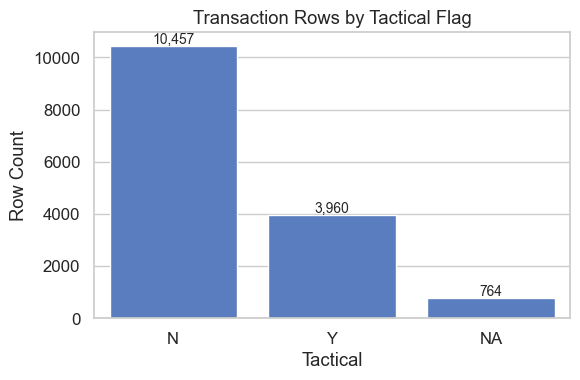

In [10]:
# Tactical distribution (3 values: Y, N, NA)
print("=" * 60)
print("TACTICAL — 3 values")
print("=" * 60)
(
    raw_df.groupBy("tactical")
    .count()
    .orderBy(F.desc("count"))
    .show(truncate=False)
)

# Visualize
tac_pd = (
    raw_df.groupBy("tactical")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=tac_pd, x="tactical", y="count", ax=ax)
ax.set_title("Transaction Rows by Tactical Flag")
ax.set_xlabel("Tactical")
ax.set_ylabel("Row Count")
for i, row in tac_pd.iterrows():
    ax.text(i, row["count"] + 100, f"{row['count']:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

---
## 4. Tactical "NA" Deep Dive

A critical data quality finding: the `tactical` column contains the **string literal
"NA"**, not Python `NaN` or `None`. This represents a valid third category (764 rows)
distinct from "N" (non-tactical) and "Y" (tactical).

The old project incorrectly treated these as missing values and filled them with "N",
merging two distinct product segments.

In [11]:
# Prove "NA" is a string, not null
na_rows = raw_df.filter(F.col("tactical") == "NA")
null_rows = raw_df.filter(F.col("tactical").isNull())

print(f"Rows where tactical == 'NA' (string literal): {na_rows.count()}")
print(f"Rows where tactical IS NULL:                   {null_rows.count()}")
print()
print("These are NOT the same thing. The 'NA' values are a valid category.")

26/02/26 16:38:34 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:38:34 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:38:34 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:38:34 WARN CSVHeaderChecker: CSV header does not confor

Rows where tactical == 'NA' (string literal): 764


26/02/26 16:38:39 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:38:39 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:38:39 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'tactical'
 Schema: tactical
Expected: tactical but found: b'tactical'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:38:39 WARN CSVHeaderChecker: CSV header does not confor

Rows where tactical IS NULL:                   0

These are NOT the same thing. The 'NA' values are a valid category.


26/02/26 16:38:47 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'year_', b'tactical'
 Schema: year_, tactical
Expected: year_ but found: b'year_'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv


26/02/26 16:38:47 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'year_', b'tactical'
 Schema: year_, tactical
Expected: year_ but found: b'year_'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:38:47 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'year_', b'tactical'
 Schema: year_, tactical
Expected: year_ but found: b'year_'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:38:47 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'year_', b'tactical'
 Schema: year_, tactical
Expected: year_ but found: b'year_'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:38:47 WARN CSVHeaderCh

Tactical 'NA' count by year:
 year_  count
  2019     31
  2020     54
  2021    117
  2022    317
  2023    245


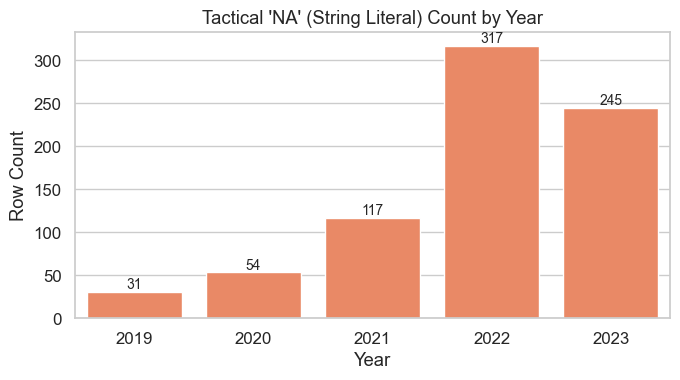

In [12]:
# "NA" count by year — shows growth from a data coding change
na_by_year = (
    raw_df.filter(F.col("tactical") == "NA")
    .groupBy("year_")
    .count()
    .orderBy("year_")
    .toPandas()
)
print("Tactical 'NA' count by year:")
print(na_by_year.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=na_by_year, x="year_", y="count", ax=ax, color="coral")
ax.set_title("Tactical 'NA' (String Literal) Count by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Row Count")
for i, row in na_by_year.iterrows():
    ax.text(i, row["count"] + 3, str(row["count"]), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
# Which products have "NA" tactical? Do they overlap with "N" products?
na_products = (
    raw_df.filter(F.col("tactical") == "NA")
    .select("subcategory", "sizing")
    .distinct()
    .toPandas()
)
n_products = (
    raw_df.filter(F.col("tactical") == "N")
    .select("subcategory", "sizing")
    .distinct()
    .toPandas()
)

# Merge to find overlap
overlap = na_products.merge(n_products, on=["subcategory", "sizing"], how="inner")
print(f"Products with 'NA' tactical: {len(na_products)}")
print(f"Products with 'N' tactical:  {len(n_products)}")
print(f"Overlap (same subcategory+sizing in both): {len(overlap)}")
print()
print("Decision: Keep 'NA' as a separate category. The model can learn")
print("whether NA and N behave differently. The growth from 31 (2019) to")
print("317 (2022) suggests a data coding change, not missing data.")

26/02/26 16:38:54 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'tactical'
 Schema: subcategory, sizing, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:38:54 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'tactical'
 Schema: subcategory, sizing, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:38:54 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'tactical'
 Schema: subcategory, sizing, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/proj

26/02/26 16:38:57 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'tactical'
 Schema: subcategory, sizing, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:38:57 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'tactical'
 Schema: subcategory, sizing, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:38:57 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'tactical'
 Schema: subcategory, sizing, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/proj

Products with 'NA' tactical: 14
Products with 'N' tactical:  43
Overlap (same subcategory+sizing in both): 13

Decision: Keep 'NA' as a separate category. The model can learn
whether NA and N behave differently. The growth from 31 (2019) to
317 (2022) suggests a data coding change, not missing data.


---
## 5. Data Quality

Check for missing values, duplicates, and anomalous records.

In [14]:
# Missing values per column
total = raw_df.count()
print("Missing values per column:")
print("-" * 40)
for col_name in raw_df.columns:
    null_count = raw_df.filter(F.col(col_name).isNull()).count()
    pct = null_count / total * 100
    if null_count > 0:
        print(f"  {col_name:20s} {null_count:6,} ({pct:.1f}%)")

print()
barrel_null = raw_df.filter(F.col("barrel_length").isNull()).count()
print(f"barrel_length is the only column with missing values:")
print(f"  {barrel_null:,} of {total:,} rows = {barrel_null/total*100:.1f}%")

Missing values per column:
----------------------------------------


26/02/26 16:39:02 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'type'
 Schema: type
Expected: type but found: b'type'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:39:02 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'type'
 Schema: type
Expected: type but found: b'type'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:39:02 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'type'
 Schema: type
Expected: type but found: b'type'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:39:02 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'type'
 Schema: type


26/02/26 16:39:02 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'category'
 Schema: category
Expected: category but found: b'category'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:39:02 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'category'
 Schema: category
Expected: category but found: b'category'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:39:03 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'category'
 Schema: category
Expected: category but found: b'category'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:39:03 WARN CSVHeaderChecker: CSV header does not confor

26/02/26 16:39:03 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory'
 Schema: subcategory
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:39:03 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory'
 Schema: subcategory
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:39:03 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory'
 Schema: subcategory
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:39:03 WARN CSVHeade

26/02/26 16:39:04 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:39:04 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:39:04 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:39:04 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header

...

26/02/26 16:39:18 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'amount'
 Schema: amount
Expected: amount but found: b'amount'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:39:18 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'amount'
 Schema: amount
Expected: amount but found: b'amount'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:39:18 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'amount'
 Schema: amount
Expected: amount but found: b'amount'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:39:18 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header

26/02/26 16:39:20 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'month_number', b'year_'
 Schema: month_number, year_
Expected: month_number but found: b'month_number'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:39:20 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'month_number', b'year_'
 Schema: month_number, year_
Expected: month_number but found: b'month_number'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:39:20 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'month_number', b'year_'
 Schema: month_number, year_
Expected: month_number but found: b'month_number'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_sho

26/02/26 16:39:21 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'barrel_length'
 Schema: barrel_length
Expected: barrel_length but found: b'barrel_length'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:39:21 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'barrel_length'
 Schema: barrel_length
Expected: barrel_length but found: b'barrel_length'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:39:21 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'barrel_length'
 Schema: barrel_length
Expected: barrel_length but found: b'barrel_length'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/2

26/02/26 16:39:22 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'barrel_length'
 Schema: barrel_length
Expected: barrel_length but found: b'barrel_length'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv


barrel_length is the only column with missing values:
  2,294 of 15,181 rows = 15.1%


In [15]:
# True duplicates at the most granular level
# Same subcategory, sizing, tactical, month, year, AND barrel_length
granular_cols = ["subcategory", "sizing", "tactical", "month_number", "year_", "barrel_length"]
dup_counts = (
    raw_df.groupBy(granular_cols)
    .count()
    .filter(F.col("count") > 1)
)

n_dup_groups = dup_counts.count()
# Total extra rows from duplicates
extra_rows = dup_counts.agg(F.sum(F.col("count") - 1)).collect()[0][0]
print(f"Duplicate groups (same product + month + barrel_length): {n_dup_groups}")
print(f"Extra rows from duplicates: {extra_rows}")
print()
print("These are summed during monthly aggregation (quantity and amount are additive).")

26/02/26 16:39:26 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical', b'barrel_length'
 Schema: subcategory, sizing, month_number, year_, tactical, barrel_length
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:39:26 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical', b'barrel_length'
 Schema: subcategory, sizing, month_number, year_, tactical, barrel_length
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:39:26 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory',

26/02/26 16:39:27 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical', b'barrel_length'
 Schema: subcategory, sizing, month_number, year_, tactical, barrel_length
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv


26/02/26 16:39:32 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical', b'barrel_length'
 Schema: subcategory, sizing, month_number, year_, tactical, barrel_length
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:39:32 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical', b'barrel_length'
 Schema: subcategory, sizing, month_number, year_, tactical, barrel_length
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:39:32 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory',

Duplicate groups (same product + month + barrel_length): 159
Extra rows from duplicates: 170

These are summed during monthly aggregation (quantity and amount are additive).


In [16]:
# Non-shotgun calibers in the data
non_shotgun = ["308 WIN/7.62 NATO", "223 REM/5.56 NATO", "338 LAUPAU MAG", "22 LR"]
non_sg_df = raw_df.filter(F.col("sizing").isin(non_shotgun))

print("Non-shotgun calibers found in 'shotgun' data:")
print("-" * 50)
(
    non_sg_df.groupBy("sizing", "subcategory")
    .agg(F.count("*").alias("rows"), F.sum("quantity").alias("total_qty"))
    .orderBy(F.desc("rows"))
    .show(truncate=False)
)
print(f"Total non-shotgun rows: {non_sg_df.count()} of {total:,} ({non_sg_df.count()/total*100:.1f}%)")
print("\nThese are combo guns (rifle/shotgun) or data quality artifacts.")
print("Kept in data — low volume, model handles them as product features.")

Non-shotgun calibers found in 'shotgun' data:
--------------------------------------------------


26/02/26 16:39:42 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'quantity'
 Schema: subcategory, sizing, quantity
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:39:42 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'quantity'
 Schema: subcategory, sizing, quantity
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:39:42 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'quantity'
 Schema: subcategory, sizing, quantity
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/proj

+-----------------+-------------+----+---------+
|sizing           |subcategory  |rows|total_qty|
+-----------------+-------------+----+---------+
|22 LR            |Single Shot  |44  |186      |
|308 WIN/7.62 NATO|Pump Action  |27  |7461     |
|22 LR            |Rifle/Shotgun|25  |184      |
|223 REM/5.56 NATO|Semiautomatic|18  |928      |
|338 LAUPAU MAG   |Side By Side |6   |3        |
+-----------------+-------------+----+---------+



26/02/26 16:39:43 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:39:43 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:39:43 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv


26/02/26 16:39:44 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:39:44 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv


26/02/26 16:39:45 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:39:45 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:39:45 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'sizing'
 Schema: sizing
Expected: sizing but found: b'sizing'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:39:45 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header

Total non-shotgun rows: 120 of 15,181 (0.8%)

These are combo guns (rifle/shotgun) or data quality artifacts.
Kept in data — low volume, model handles them as product features.


---
## 6. Product Matrix

There are 74 unique (subcategory, sizing, tactical) product combinations across the
full dataset. Many are sparse — present in only a fraction of the 60 possible months.
The heatmap below shows months-of-data per product.

In [17]:
# Count distinct products
products = raw_df.select("subcategory", "sizing", "tactical").distinct()
n_products = products.count()
print(f"Unique (subcategory, sizing, tactical) combinations: {n_products}")

26/02/26 16:39:46 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'tactical'
 Schema: subcategory, sizing, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:39:46 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'tactical'
 Schema: subcategory, sizing, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:39:46 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'tactical'
 Schema: subcategory, sizing, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/proj

Unique (subcategory, sizing, tactical) combinations: 74


26/02/26 16:39:52 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical'
 Schema: subcategory, sizing, month_number, year_, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 16:39:52 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical'
 Schema: subcategory, sizing, month_number, year_, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2022.csv
26/02/26 16:39:52 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical'
 Schema: subcat

26/02/26 16:39:53 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical'
 Schema: subcategory, sizing, month_number, year_, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv


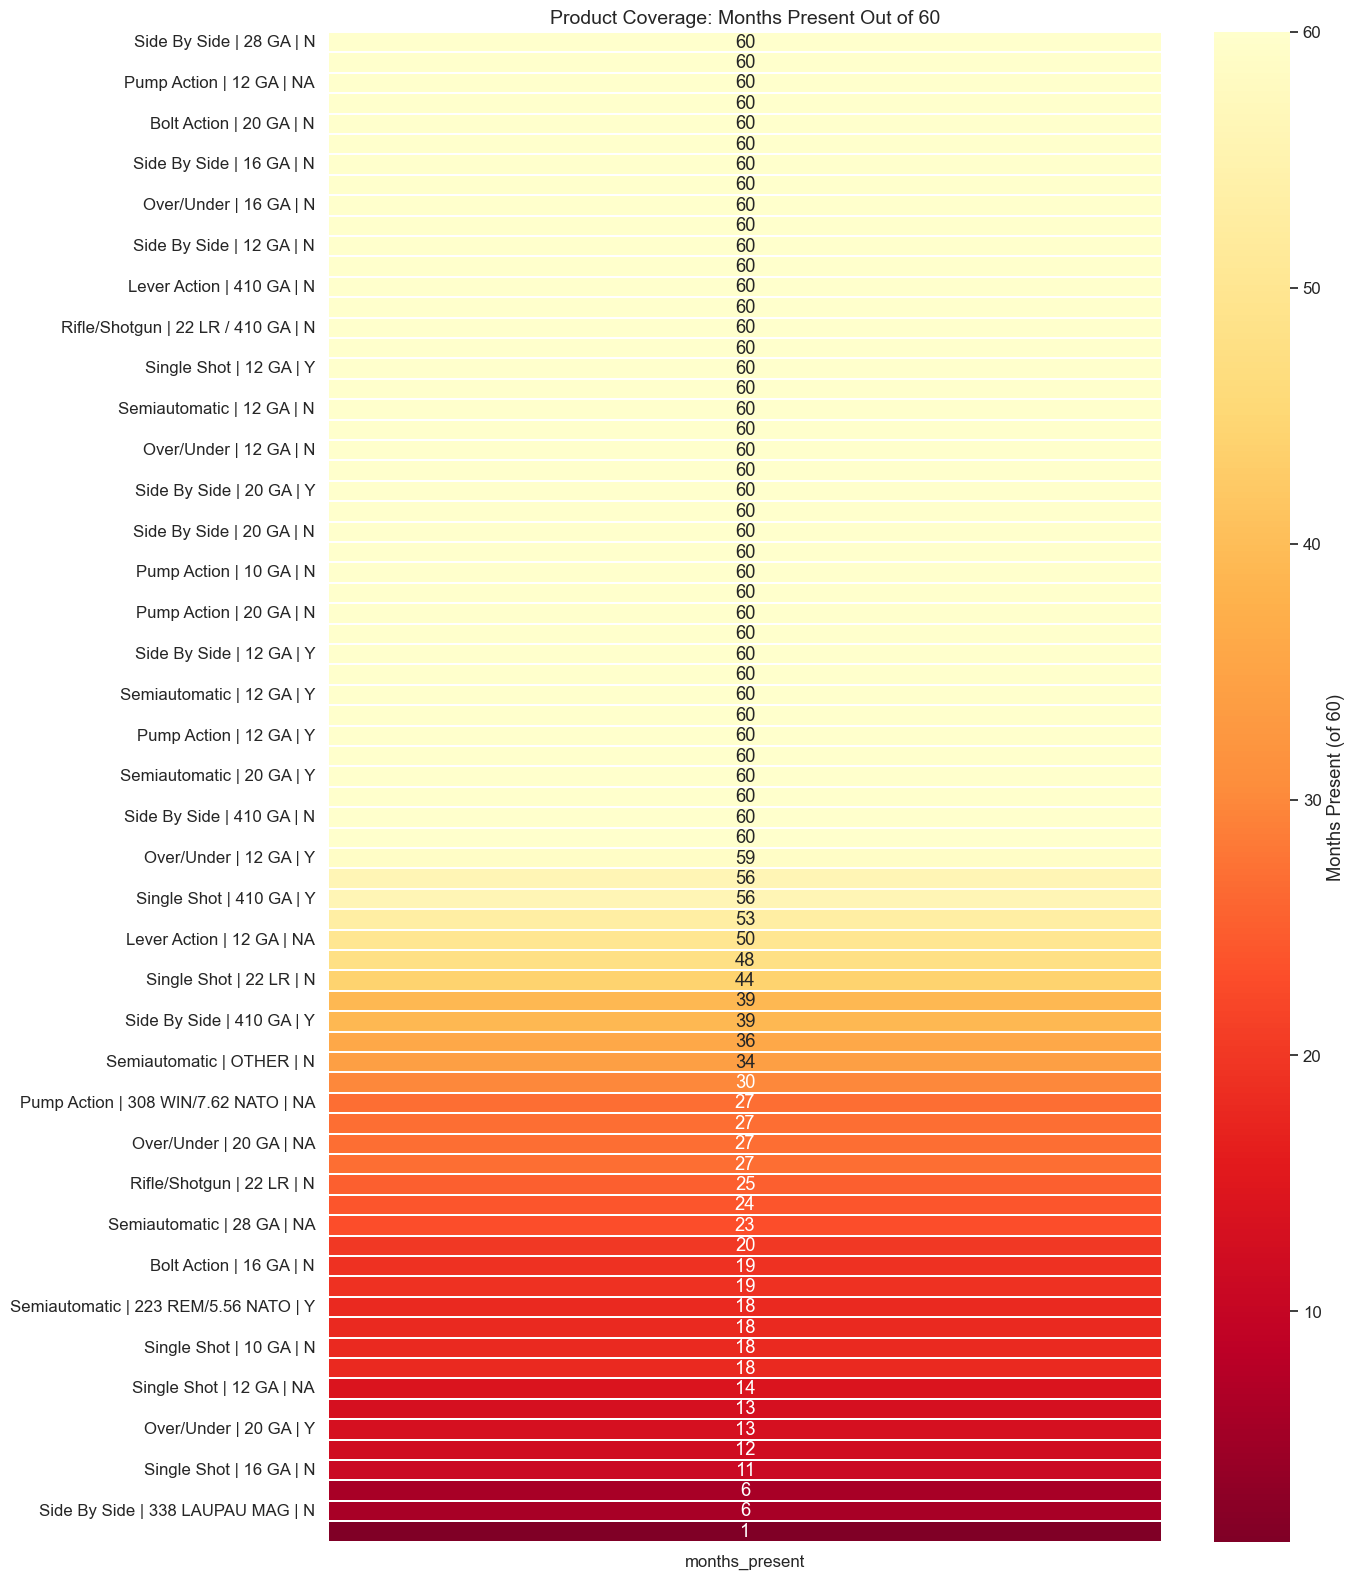


Coverage summary (of 60 possible months):
  Full coverage (60/60): 40 products
  High (>= 48 months):   46 products
  Medium (24-47 months): 12 products
  Low (< 24 months):     16 products


In [18]:
# Months present per product — heatmap
months_present = (
    raw_df.select("subcategory", "sizing", "tactical", "year_", "month_number")
    .distinct()
    .groupBy("subcategory", "sizing", "tactical")
    .count()
    .withColumnRenamed("count", "months_present")
    .toPandas()
)

# Create a product label for display
months_present["product"] = (
    months_present["subcategory"] + " | " +
    months_present["sizing"] + " | " +
    months_present["tactical"]
)
months_present = months_present.sort_values("months_present", ascending=False)

# Pivot for heatmap: products vs coverage bucket
fig, ax = plt.subplots(figsize=(14, 16))
pivot = months_present.set_index("product")[["months_present"]]

sns.heatmap(
    pivot,
    annot=True, fmt="d", cmap="YlOrRd_r",
    cbar_kws={"label": "Months Present (of 60)"},
    linewidths=0.3,
    ax=ax,
)
ax.set_title("Product Coverage: Months Present Out of 60", fontsize=14)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nCoverage summary (of 60 possible months):")
print(f"  Full coverage (60/60): {(months_present['months_present'] == 60).sum()} products")
print(f"  High (>= 48 months):   {(months_present['months_present'] >= 48).sum()} products")
print(f"  Medium (24-47 months): {((months_present['months_present'] >= 24) & (months_present['months_present'] < 48)).sum()} products")
print(f"  Low (< 24 months):     {(months_present['months_present'] < 24).sum()} products")

---
## 7. Distributions

Examine quantity and amount distributions, monthly aggregate patterns (March peak),
and year-over-year trends (COVID surge).

26/02/26 16:40:12 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'quantity', b'amount'
 Schema: quantity, amount
Expected: quantity but found: b'quantity'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv


26/02/26 16:40:13 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'quantity', b'amount'
 Schema: quantity, amount
Expected: quantity but found: b'quantity'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:40:13 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'quantity', b'amount'
 Schema: quantity, amount
Expected: quantity but found: b'quantity'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:40:13 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'quantity', b'amount'
 Schema: quantity, amount
Expected: quantity but found: b'quantity'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2023.csv
26/02/26 1

/Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


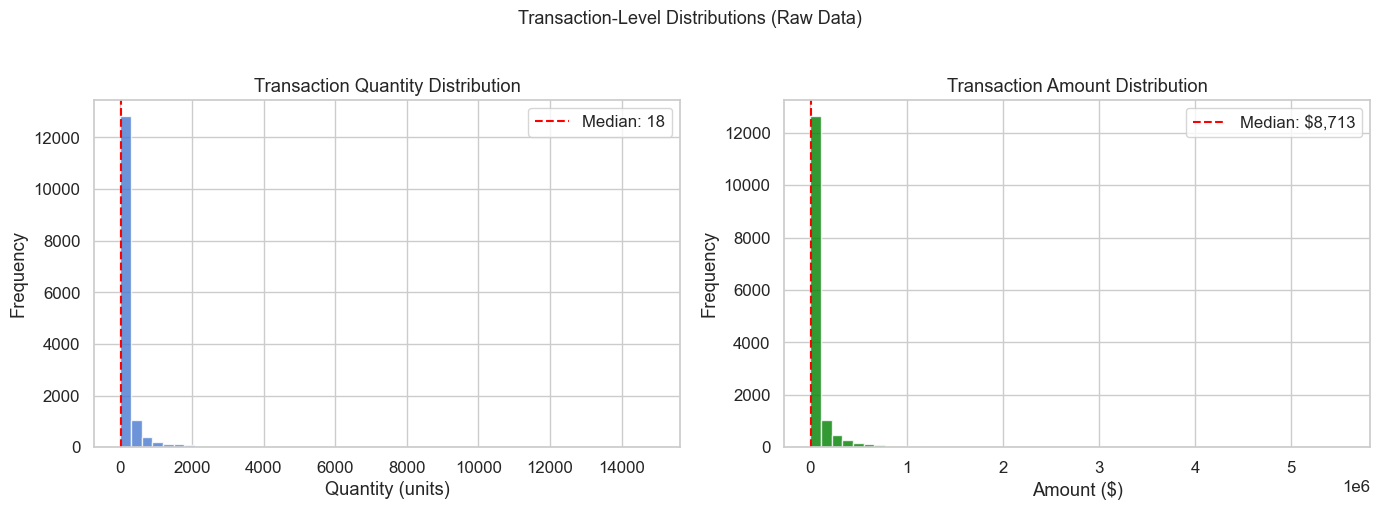

In [19]:
# Transaction-level quantity and amount histograms
raw_pd = raw_df.select("quantity", "amount").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(raw_pd["quantity"], bins=50, edgecolor="white", alpha=0.8)
axes[0].set_title("Transaction Quantity Distribution")
axes[0].set_xlabel("Quantity (units)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(raw_pd["quantity"].median(), color="red", linestyle="--",
                label=f"Median: {raw_pd['quantity'].median():.0f}")
axes[0].legend()

axes[1].hist(raw_pd["amount"], bins=50, edgecolor="white", alpha=0.8, color="green")
axes[1].set_title("Transaction Amount Distribution")
axes[1].set_xlabel("Amount ($)")
axes[1].set_ylabel("Frequency")
axes[1].axvline(raw_pd["amount"].median(), color="red", linestyle="--",
                label=f"Median: ${raw_pd['amount'].median():,.0f}")
axes[1].legend()

plt.suptitle("Transaction-Level Distributions (Raw Data)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

26/02/26 16:40:25 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'month_number', b'year_', b'quantity', b'amount'
 Schema: month_number, year_, quantity, amount
Expected: month_number but found: b'month_number'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:40:25 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'month_number', b'year_', b'quantity', b'amount'
 Schema: month_number, year_, quantity, amount
Expected: month_number but found: b'month_number'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2019.csv
26/02/26 16:40:25 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'month_number', b'year_', b'quantity', b'amount'
 Schema: month_number, year_, quantity, amount
Expected: month_number but found: b'mo

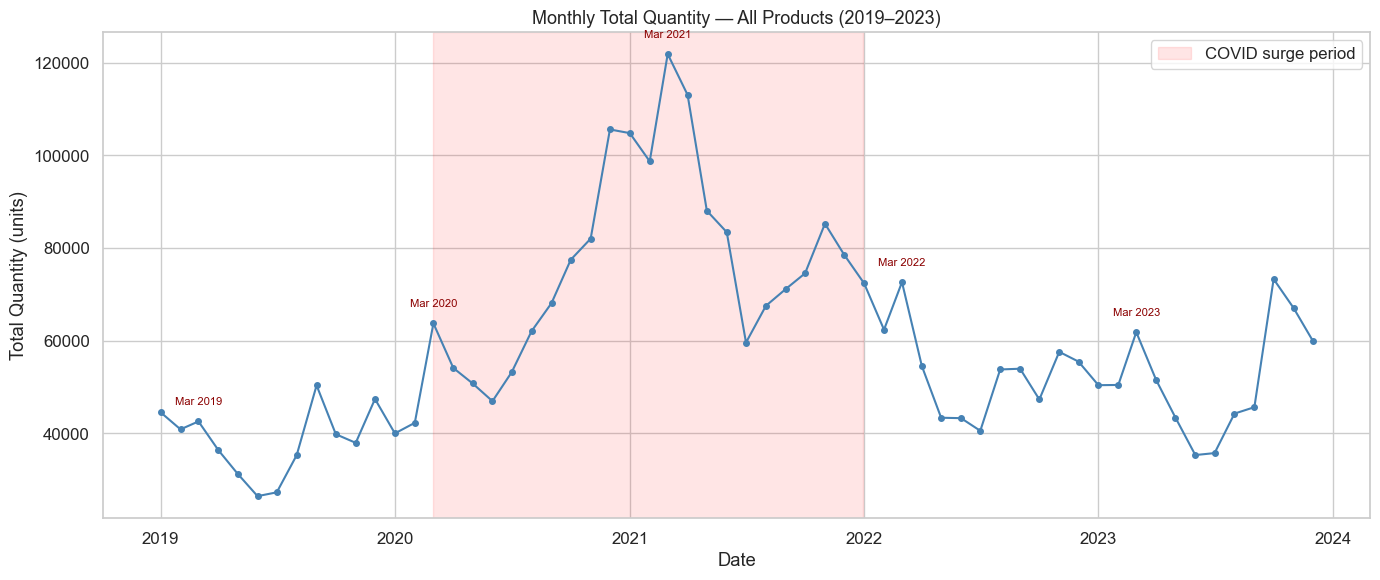

In [20]:
# Monthly aggregate: total quantity by month across all products
monthly_agg = (
    raw_df.groupBy("date")
    .agg(F.sum("quantity").alias("total_quantity"), F.sum("amount").alias("total_amount"))
    .orderBy("date")
    .toPandas()
)
monthly_agg["date"] = pd.to_datetime(monthly_agg["date"])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_agg["date"], monthly_agg["total_quantity"],
        marker="o", markersize=4, linewidth=1.5, color="steelblue")

# Annotate March peaks
march_data = monthly_agg[monthly_agg["date"].dt.month == 3]
for _, row in march_data.iterrows():
    ax.annotate(
        f"Mar {row['date'].year}",
        xy=(row["date"], row["total_quantity"]),
        xytext=(0, 12), textcoords="offset points",
        fontsize=8, ha="center", color="darkred",
    )

# Shade COVID period
ax.axvspan(
    pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-31"),
    alpha=0.1, color="red", label="COVID surge period",
)

ax.set_title("Monthly Total Quantity — All Products (2019–2023)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Total Quantity (units)")
ax.legend()
plt.tight_layout()
plt.show()

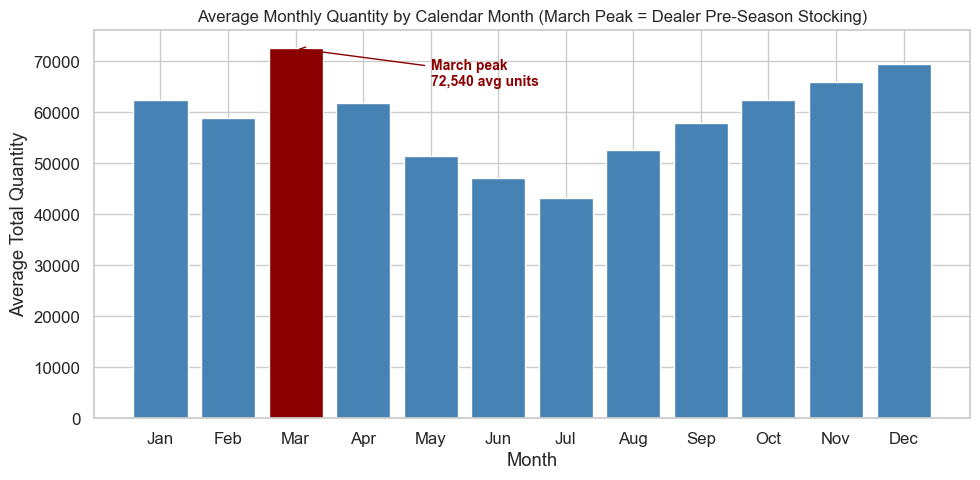

In [21]:
# Monthly seasonality: average quantity by month across years
monthly_agg["month"] = monthly_agg["date"].dt.month
monthly_agg["year"] = monthly_agg["date"].dt.year

month_avg = monthly_agg.groupby("month")["total_quantity"].mean().reset_index()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(month_avg["month"], month_avg["total_quantity"],
              color=["darkred" if m == 3 else "steelblue" for m in month_avg["month"]],
              edgecolor="white")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title("Average Monthly Quantity by Calendar Month (March Peak = Dealer Pre-Season Stocking)",
             fontsize=12)
ax.set_xlabel("Month")
ax.set_ylabel("Average Total Quantity")

# Annotate March bar
march_val = month_avg[month_avg["month"] == 3]["total_quantity"].values[0]
ax.annotate(
    f"March peak\n{march_val:,.0f} avg units",
    xy=(3, march_val), xytext=(5, march_val * 0.9),
    arrowprops=dict(arrowstyle="->", color="darkred"),
    fontsize=10, color="darkred", fontweight="bold",
)
plt.tight_layout()
plt.show()

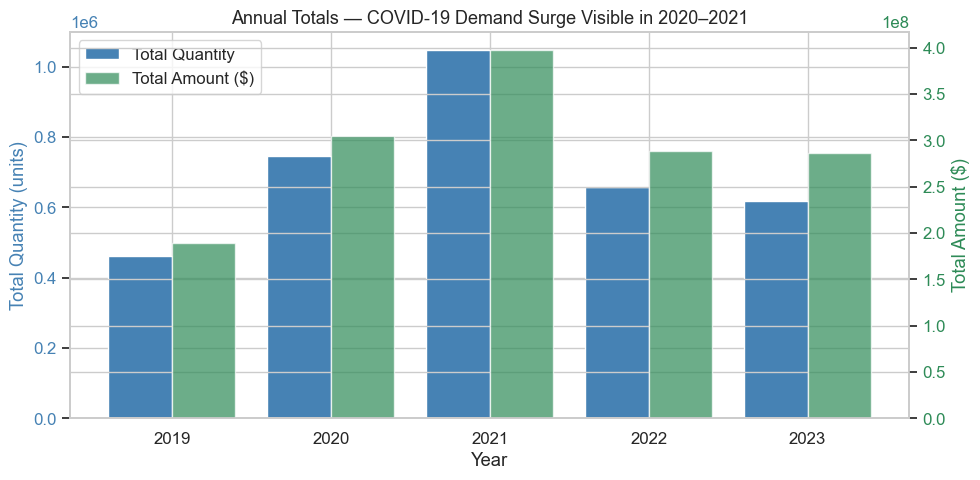

Year-over-year quantity change:
  2020.0: 746,502 (+62.1% vs 2019.0)
  2021.0: 1,046,496 (+40.2% vs 2020.0)
  2022.0: 657,456 (-37.2% vs 2021.0)
  2023.0: 619,178 (-5.8% vs 2022.0)


In [22]:
# Year-over-year trend: annual total and COVID surge
annual = monthly_agg.groupby("year").agg(
    total_qty=("total_quantity", "sum"),
    total_amt=("total_amount", "sum"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

color_qty = "steelblue"
color_amt = "seagreen"

bars = ax1.bar(annual["year"] - 0.2, annual["total_qty"], 0.4,
               label="Total Quantity", color=color_qty, edgecolor="white")
ax1.set_xlabel("Year")
ax1.set_ylabel("Total Quantity (units)", color=color_qty)
ax1.tick_params(axis="y", labelcolor=color_qty)

ax2 = ax1.twinx()
ax2.bar(annual["year"] + 0.2, annual["total_amt"], 0.4,
        label="Total Amount ($)", color=color_amt, alpha=0.7, edgecolor="white")
ax2.set_ylabel("Total Amount ($)", color=color_amt)
ax2.tick_params(axis="y", labelcolor=color_amt)

ax1.set_xticks(YEARS)
ax1.set_title("Annual Totals — COVID-19 Demand Surge Visible in 2020–2021", fontsize=13)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

# Print year-over-year changes
print("Year-over-year quantity change:")
for i in range(1, len(annual)):
    prev = annual.iloc[i - 1]["total_qty"]
    curr = annual.iloc[i]["total_qty"]
    pct = (curr - prev) / prev * 100
    print(f"  {annual.iloc[i]['year']}: {curr:,.0f} ({pct:+.1f}% vs {annual.iloc[i-1]['year']})")

---
## 8. Pipeline Output Verification

Load the processed Parquet output from the pipeline and verify:
- Shape (~4,440 rows = 74 products x 60 months)
- Zero-fill correctness (sparse products now have 60 rows)
- Summary statistics

In [23]:
# Load processed Parquet
processed_df = spark.read.parquet(str(PROCESSED_DIR))

proc_count = processed_df.count()
n_proc_products = processed_df.select("subcategory", "sizing", "tactical").distinct().count()
n_months = processed_df.select("date").distinct().count()

print(f"Processed data shape: {proc_count:,} rows")
print(f"Distinct products:    {n_proc_products}")
print(f"Distinct months:      {n_months}")
print(f"Expected (products x months): {n_proc_products} x {n_months} = {n_proc_products * n_months:,}")
print(f"Match: {'YES' if proc_count == n_proc_products * n_months else 'NO'}")
print()
processed_df.printSchema()

Processed data shape: 4,440 rows
Distinct products:    74
Distinct months:      60
Expected (products x months): 74 x 60 = 4,440
Match: YES

root
 |-- subcategory: string (nullable = true)
 |-- sizing: string (nullable = true)
 |-- tactical: string (nullable = true)
 |-- date: date (nullable = true)
 |-- quantity: long (nullable = true)
 |-- amount: double (nullable = true)
 |-- barrel_length: double (nullable = true)
 |-- transaction_count: long (nullable = true)
 |-- avg_price: double (nullable = true)



In [24]:
# Verify zero-fill: pick a sparse product and confirm it now has 60 rows
# Find a product with few actual transactions
actual_months = (
    raw_df.select("subcategory", "sizing", "tactical", "year_", "month_number")
    .distinct()
    .groupBy("subcategory", "sizing", "tactical")
    .count()
    .withColumnRenamed("count", "actual_months")
    .orderBy("actual_months")
)

# Get the sparsest product
sparse = actual_months.first()
sparse_sub = sparse["subcategory"]
sparse_siz = sparse["sizing"]
sparse_tac = sparse["tactical"]
sparse_actual = sparse["actual_months"]

# Count in processed data
filled_count = (
    processed_df.filter(
        (F.col("subcategory") == sparse_sub) &
        (F.col("sizing") == sparse_siz) &
        (F.col("tactical") == sparse_tac)
    ).count()
)

print(f"Sparse product: {sparse_sub} | {sparse_siz} | {sparse_tac}")
print(f"  Actual months in raw data: {sparse_actual}")
print(f"  Rows in processed output:  {filled_count}")
print(f"  Zero-fill working: {'YES' if filled_count == 60 else 'NO'} (expected 60)")

26/02/26 16:41:11 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical'
 Schema: subcategory, sizing, month_number, year_, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2020.csv
26/02/26 16:41:11 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical'
 Schema: subcategory, sizing, month_number, year_, tactical
Expected: subcategory but found: b'subcategory'
CSV file: file:///Users/brentthomas1/Developer/projects/active/scope-term-project/new/scope-final/data/raw/dlx_shotgun_datadump_firearms_2021.csv
26/02/26 16:41:11 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: b'subcategory', b'sizing', b'month_number', b'year_', b'tactical'
 Schema: subcat

Sparse product: Semiautomatic | 410 GA | NA
  Actual months in raw data: 1
  Rows in processed output:  60
  Zero-fill working: YES (expected 60)


In [25]:
# Summary statistics on processed data
print("Processed data summary statistics:")
processed_df.select("quantity", "amount", "barrel_length", "avg_price", "transaction_count").describe().show()

# Check for nulls in key columns
print("Null check on processed data:")
key_cols = ["date", "subcategory", "sizing", "tactical", "quantity", "amount"]
for col_name in key_cols:
    null_count = processed_df.filter(F.col(col_name).isNull()).count()
    print(f"  {col_name:20s} nulls: {null_count}")

Processed data summary statistics:


26/02/26 16:41:23 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+--------------------+------------------+------------------+------------------+
|summary|         quantity|              amount|     barrel_length|         avg_price| transaction_count|
+-------+-----------------+--------------------+------------------+------------------+------------------+
|  count|             4440|                4440|              4440|              4440|              4440|
|   mean|795.0804054054054|  329992.96138264425|23.219342684644314|322.01694421566594|3.4191441441441444|
| stddev| 2649.53771628207|  1088703.1733943769|3.3656980500147555| 347.7787439686784| 3.911874838880735|
|    min|                0|                 0.0|              10.0|               0.0|                 0|
|    max|            35649|1.6350148545898438E7|              29.0|            5250.0|                20|
+-------+-----------------+--------------------+------------------+------------------+------------------+

Null check on processed data:


  date                 nulls: 0
  subcategory          nulls: 0


  sizing               nulls: 0


  tactical             nulls: 0


  quantity             nulls: 0


  amount               nulls: 0


In [26]:
# Zero-quantity rows (from zero-fill) vs non-zero
zero_qty = processed_df.filter(F.col("quantity") == 0).count()
nonzero_qty = processed_df.filter(F.col("quantity") > 0).count()

print(f"Processed rows with quantity == 0 (from zero-fill): {zero_qty:,}")
print(f"Processed rows with quantity  > 0 (actual demand):  {nonzero_qty:,}")
print(f"Zero-inflated ratio: {zero_qty / proc_count * 100:.1f}%")

Processed rows with quantity == 0 (from zero-fill): 1,661
Processed rows with quantity  > 0 (actual demand):  2,779
Zero-inflated ratio: 37.4%


---
## 9. Key Findings Summary

### Data Source
- **Source:** NASGW SCOPE DLX platform — this is **distributor sell-in data**
  (wholesale-to-dealer), not consumer sell-through
- **Scope:** 5 years (2019–2023), 15,181 raw transaction rows, 74 unique
  (subcategory, sizing, tactical) product combinations

### Critical Data Quality Findings

1. **Tactical "NA" is a valid category** — The `tactical` column contains the
   string literal `"NA"` (764 rows), not Python `NaN`. This is a third product
   segment that grew from 31 rows (2019) to 317 rows (2022), indicating a data
   coding change. We keep it as a separate category.

2. **Missing barrel_length** — 2,294 rows (15.1%) have null barrel_length.
   Handled via per-product mean imputation after aggregation.

3. **True duplicates** — 159 exact duplicates at the most granular level.
   Quantities are summed during monthly aggregation.

4. **Non-shotgun calibers** — 308 WIN, 223 REM, 338 LAPUA, 22 LR appear in
   the shotgun category (combo guns). Low volume; kept in data.

### Demand Patterns

5. **March peak** — Consistent annual peak in March reflects **dealer
   pre-season stocking** (retailers order ahead of fall hunting season),
   not consumer buying.

6. **COVID structural break** — 2020–2021 saw a massive demand surge driven
   by pandemic-era firearms buying. This is a structural break the model must
   account for via regime indicators.

### Pipeline Design Decisions

7. **Zero-fill is required** — Many of the 74 products have sparse monthly
   coverage. The processed panel zero-fills all product x month combinations
   (~4,440 rows) so that time-series features (lags, rolling means) work
   correctly.

8. **Panel (global) model** — With only 60 months per product, individual
   models are infeasible. A global model trained across all products with
   product features as inputs is the correct approach.

In [27]:
# Cleanup
spark.stop()
print("SparkSession stopped. Notebook complete.")

SparkSession stopped. Notebook complete.
